In [1]:
import numpy as np, tools_multitracer as mass, pickle, curvedsky as cs, healpy as hp, local
from matplotlib.pyplot import *

In [5]:
import importlib
importlib.reload(local)

<module 'local' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-lens/local.py'>

In [6]:
lmax = 1024
rlz  = 1
ctypes = ['klb','cib','gal','ext','all']

In [4]:
klm = {}
#klm[0], klm[1], klm[2], klm[3], klm[4] = pickle.load(open(mobj.fwklm[rlz],"rb"))

In [5]:
for ctype in ctypes:
    mobj = mass.comb_mobj(ctype,lmax=lmax)
    klm[ctype] = pickle.load(open(mobj.fwklm[rlz],"rb"))

In [6]:
glob  = local.analysis()
iklm  = glob.load_input_kappa(rlz,lmax)

In [7]:
kmap = {ctype: cs.utils.hp_alm2map(512,lmax,lmax,klm[ctype]) for ctype in ctypes}

In [8]:
ikmap = cs.utils.hp_alm2map(512,lmax,lmax,iklm)

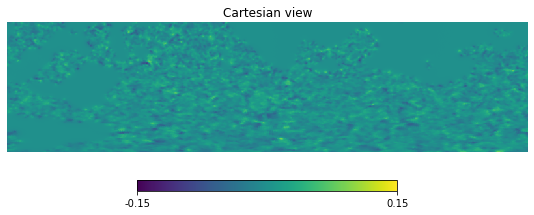

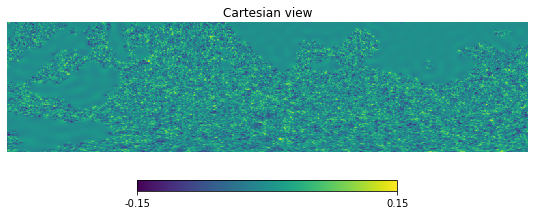

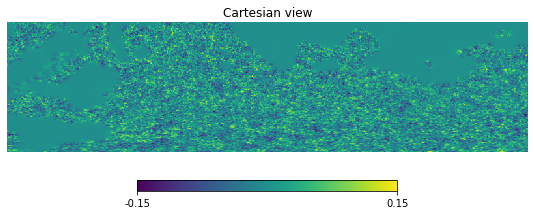

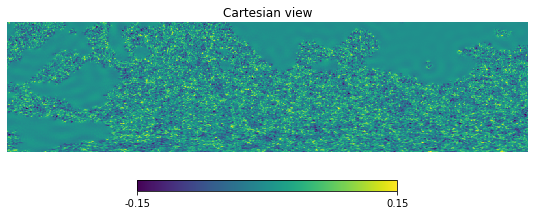

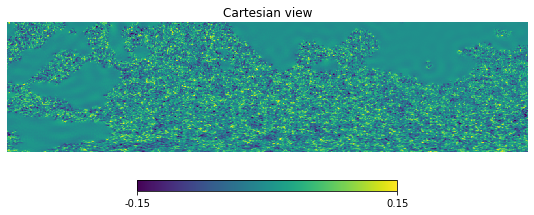

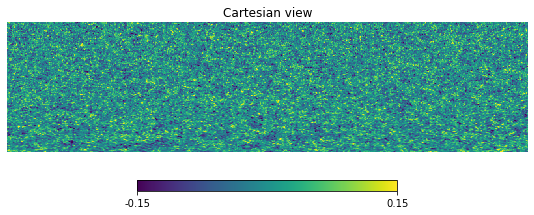

In [9]:
lonra, latra = [-80,80], [-70,-30]
for ctype in ctypes:
    hp.cartview(kmap[ctype],lonra=lonra,latra=latra,min=-.15,max=.15)
hp.cartview(ikmap,lonra=lonra,latra=latra,min=-.15,max=.15)

In [10]:
xcl = {ctype: cs.utils.alm2cl(lmax,iklm,klm[ctype]) for ctype in ctypes}

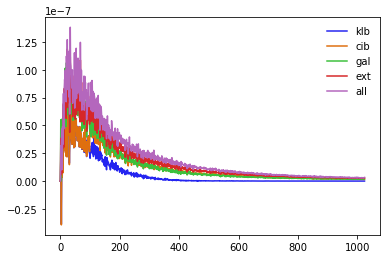

In [11]:
for ctype in ctypes:
    plot(xcl[ctype],label=ctype)
legend()